In [1]:
# Cell 1 — Import libraries and set display options

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Libraries imported.")


Libraries imported.


In [2]:
# Cell 2 — Load preprocessed datasets with cluster labels

processed_path = "../data/processed"

train_df = pd.read_csv(f"{processed_path}/train_with_clusters.csv")
val_df   = pd.read_csv(f"{processed_path}/val_with_clusters.csv")
test_df  = pd.read_csv(f"{processed_path}/test_with_clusters.csv")

print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

train_df.head()


Train shape: (7866, 13)
Val shape:   (2245, 13)
Test shape:  (1124, 13)


,Age,Gender,Occupation,Country,Sleep_Hours_Scaled,Work_Hours_Scaled,Physical_Activity_Hours_Scaled,Social_Media_Usage_Scaled,Diet_Quality_Encoded_Scaled,Smoking_Habit_Encoded_Scaled,Alcohol_Consumption_Encoded_Scaled,Stress_Level,Cluster
0,59,Prefer not to say,Healthcare,Germany,0.566667,0.94,0.3,0.200000,0.5,1.000000,0.666667,High,1
1,60,Non-binary,IT,Canada,0.450000,0.70,0.7,0.618182,1.0,0.333333,0.000000,Medium,1
2,49,Non-binary,Sales,Canada,0.666667,0.66,0.3,0.872727,0.0,1.000000,0.333333,High,0
3,37,Male,Healthcare,USA,0.916667,0.18,0.4,0.054545,0.0,0.333333,1.000000,Low,0
4,35,Female,IT,Other,0.850000,0.96,0.9,0.345455,1.0,1.000000,1.000000,High,1


In [3]:
# Cell 3 — Define lifestyle features, cluster feature, and target

target_col = "Stress_Level"

# 7 lifestyle habits (scaled)
lifestyle_features = [
    col for col in train_df.columns
    if col.endswith("_Scaled") and not col.startswith("Age")
]

print("Lifestyle features:")
print(lifestyle_features)

# Cluster column created in Notebook 03
cluster_feature = ["Cluster"]

# Model A = lifestyle only (baseline)
features_A = lifestyle_features.copy()

# Model B = lifestyle + cluster (main model in thesis)
features_B = lifestyle_features + cluster_feature

print("\nModel A features (Lifestyle only):")
print(features_A)

print("\nModel B features (Lifestyle + Cluster):")
print(features_B)

print("\nUnique Stress Levels in training set:")
print(train_df[target_col].unique())


Lifestyle features:
['Sleep_Hours_Scaled', 'Work_Hours_Scaled', 'Physical_Activity_Hours_Scaled', 'Social_Media_Usage_Scaled', 'Diet_Quality_Encoded_Scaled', 'Smoking_Habit_Encoded_Scaled', 'Alcohol_Consumption_Encoded_Scaled']

Model A features (Lifestyle only):
['Sleep_Hours_Scaled', 'Work_Hours_Scaled', 'Physical_Activity_Hours_Scaled', 'Social_Media_Usage_Scaled', 'Diet_Quality_Encoded_Scaled', 'Smoking_Habit_Encoded_Scaled', 'Alcohol_Consumption_Encoded_Scaled']

Model B features (Lifestyle + Cluster):
['Sleep_Hours_Scaled', 'Work_Hours_Scaled', 'Physical_Activity_Hours_Scaled', 'Social_Media_Usage_Scaled', 'Diet_Quality_Encoded_Scaled', 'Smoking_Habit_Encoded_Scaled', 'Alcohol_Consumption_Encoded_Scaled', 'Cluster']

Unique Stress Levels in training set:
['High' 'Medium' 'Low']


In [4]:
# Cell 4 — Prepare X and y for both models (same y, different X)

# Targets (categorical: "Low", "Medium", "High")
y_train = train_df[target_col]
y_val   = val_df[target_col]
y_test  = test_df[target_col]

# MODEL A — Lifestyle only
X_train_A = train_df[features_A]
X_val_A   = val_df[features_A]
X_test_A  = test_df[features_A]

# MODEL B — Lifestyle + Cluster
X_train_B = train_df[features_B]
X_val_B   = val_df[features_B]
X_test_B  = test_df[features_B]

print("Model A shapes:")
print("  X_train_A:", X_train_A.shape, " y_train:", y_train.shape)
print("  X_val_A:  ", X_val_A.shape,   " y_val:", y_val.shape)
print("  X_test_A: ", X_test_A.shape,  " y_test:", y_test.shape)

print("\nModel B shapes:")
print("  X_train_B:", X_train_B.shape)
print("  X_val_B:  ", X_val_B.shape)
print("  X_test_B: ", X_test_B.shape)


Model A shapes:
  X_train_A: (7866, 7)  y_train: (7866,)
  X_val_A:   (2245, 7)  y_val: (2245,)
  X_test_A:  (1124, 7)  y_test: (1124,)

Model B shapes:
  X_train_B: (7866, 8)
  X_val_B:   (2245, 8)
  X_test_B:  (1124, 8)


In [5]:
# Cell 5 — Train Model A (Multinomial Logistic Regression, lifestyle only)

model_A = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

model_A.fit(X_train_A, y_train)

print("Model A trained (lifestyle only).")


Model A trained (lifestyle only).


c:\Users\James\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [6]:
# Cell 6 — Evaluate Model A on validation and test sets

# Validation
val_pred_A = model_A.predict(X_val_A)
val_acc_A = accuracy_score(y_val, val_pred_A)

print("===== MODEL A (Lifestyle Only) — VALIDATION =====")
print("Validation Accuracy:", round(val_acc_A, 4))
print(classification_report(y_val, val_pred_A, digits=3))

# Test
test_pred_A = model_A.predict(X_test_A)
test_acc_A = accuracy_score(y_test, test_pred_A)

print("\n===== MODEL A (Lifestyle Only) — TEST =====")
print("Test Accuracy:", round(test_acc_A, 4))
print(classification_report(y_test, test_pred_A, digits=3))


===== MODEL A (Lifestyle Only) — VALIDATION =====
Validation Accuracy: 0.939
              precision    recall  f1-score   support

        High      0.956     0.962     0.959      1077
         Low      0.972     0.946     0.959       591
      Medium      0.875     0.889     0.882       577

    accuracy                          0.939      2245
   macro avg      0.934     0.932     0.933      2245
weighted avg      0.939     0.939     0.939      2245


===== MODEL A (Lifestyle Only) — TEST =====
Test Accuracy: 0.9342
              precision    recall  f1-score   support

        High      0.959     0.948     0.953       539
         Low      0.979     0.939     0.959       296
      Medium      0.850     0.903     0.876       289

    accuracy                          0.934      1124
   macro avg      0.929     0.930     0.929      1124
weighted avg      0.936     0.934     0.935      1124



In [7]:
# Cell 7 — Train Model B (Multinomial Logistic Regression, lifestyle + cluster)

model_B = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

model_B.fit(X_train_B, y_train)

print("Model B trained (lifestyle + cluster).")


Model B trained (lifestyle + cluster).


c:\Users\James\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [8]:
# Cell 8 — Evaluate Model B on validation and test sets

# Validation
val_pred_B = model_B.predict(X_val_B)
val_acc_B = accuracy_score(y_val, val_pred_B)

print("===== MODEL B (Lifestyle + Cluster) — VALIDATION =====")
print("Validation Accuracy:", round(val_acc_B, 4))
print(classification_report(y_val, val_pred_B, digits=3))

# Test
test_pred_B = model_B.predict(X_test_B)
test_acc_B = accuracy_score(y_test, test_pred_B)

print("\n===== MODEL B (Lifestyle + Cluster) — TEST =====")
print("Test Accuracy:", round(test_acc_B, 4))
print(classification_report(y_test, test_pred_B, digits=3))


===== MODEL B (Lifestyle + Cluster) — VALIDATION =====
Validation Accuracy: 0.9354
              precision    recall  f1-score   support

        High      0.955     0.956     0.956      1077
         Low      0.972     0.942     0.957       591
      Medium      0.864     0.889     0.876       577

    accuracy                          0.935      2245
   macro avg      0.930     0.929     0.930      2245
weighted avg      0.936     0.935     0.936      2245


===== MODEL B (Lifestyle + Cluster) — TEST =====
Test Accuracy: 0.9324
              precision    recall  f1-score   support

        High      0.953     0.946     0.950       539
         Low      0.979     0.946     0.962       296
      Medium      0.851     0.893     0.872       289

    accuracy                          0.932      1124
   macro avg      0.928     0.928     0.928      1124
weighted avg      0.934     0.932     0.933      1124



In [9]:
# Cell 9 — Compare performance of Model A vs Model B (Test set)

print("===== FINAL TEST ACCURACY COMPARISON =====")
print(f"Model A (Lifestyle Only):      {test_acc_A:.4f}")
print(f"Model B (Lifestyle + Cluster): {test_acc_B:.4f}")

if test_acc_B > test_acc_A:
    print("\nAdding cluster labels improved stress-level classification.")
elif test_acc_B < test_acc_A:
    print("\nAdding cluster labels did not improve performance (cluster may be redundant).")
else:
    print("\nBoth models achieved the same test accuracy.")


===== FINAL TEST ACCURACY COMPARISON =====
Model A (Lifestyle Only):      0.9342
Model B (Lifestyle + Cluster): 0.9324

Adding cluster labels did not improve performance (cluster may be redundant).


In [14]:
# Cell 10 — Save main model (Model B: lifestyle + cluster) and config for web app

import os
import joblib
import json

models_path = "../models"
os.makedirs(models_path, exist_ok=True)

# Save Model B (main)
joblib.dump(model_B, os.path.join(models_path, "multinomial_logreg_lifestyle_cluster.pkl"))

# Save feature config (for web app input order)
config = {
    "features_model_A": features_A,          # lifestyle only
    "features_model_B": features_B,          # lifestyle + cluster
    "target": target_col,
    "classes": sorted(list(y_train.unique()))   # e.g. ['High', 'Low', 'Medium'] depending on order
}

with open(os.path.join(models_path, "model_config.json"), "w") as f:
    json.dump(config, f, indent=4)

print("Model B and config saved to ../models")


Model B and config saved to ../models


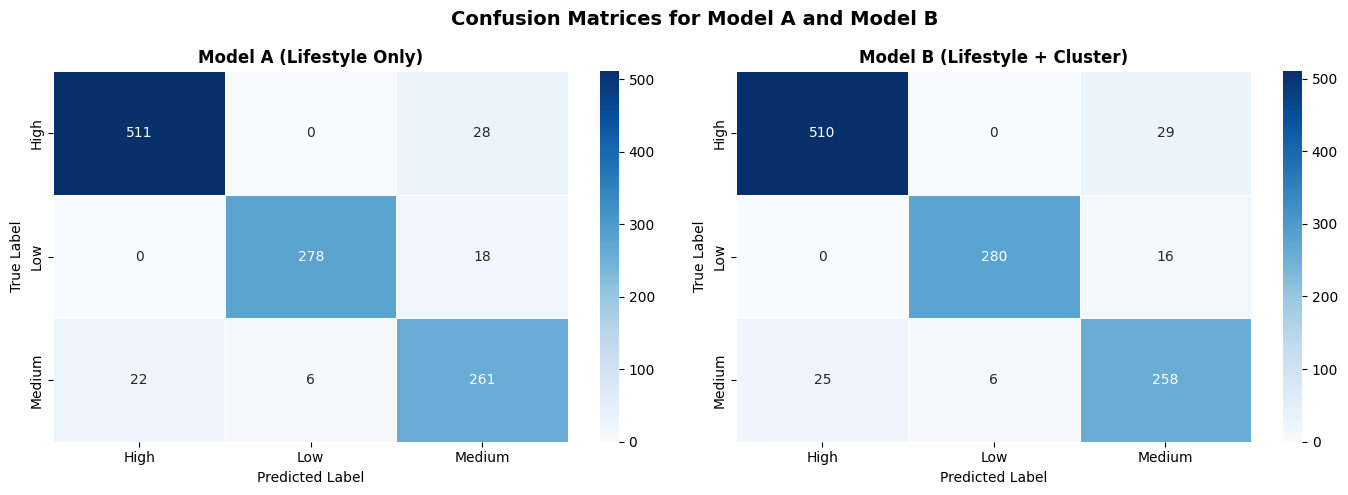

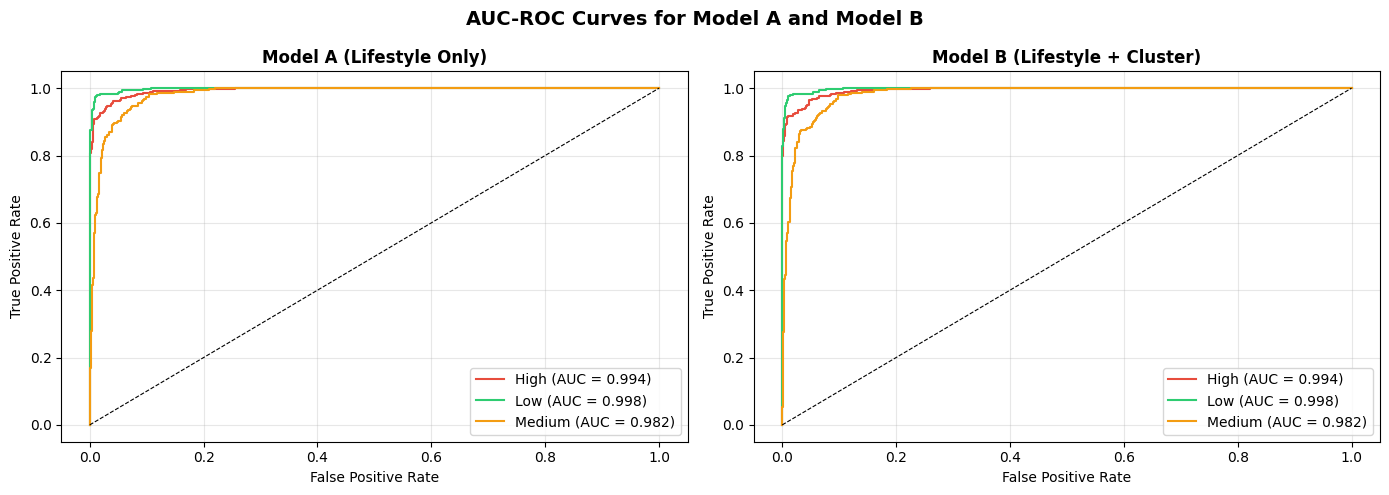

Model A Macro AUC-ROC: 0.9915
Model B Macro AUC-ROC: 0.9914


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import numpy as np

# Get predictions and probabilities
# Model A
test_pred_A = model_A.predict(X_test_A)
test_prob_A = model_A.predict_proba(X_test_A)

# Model B
test_pred_B = model_B.predict(X_test_B)
test_prob_B = model_B.predict_proba(X_test_B)

classes = ['High', 'Low', 'Medium']
y_test_bin = label_binarize(y_test, classes=classes)

# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in zip(axes,
                           [test_pred_A, test_pred_B],
                           ['Model A (Lifestyle Only)',
                            'Model B (Lifestyle + Cluster)']):
    cm = confusion_matrix(y_test, pred, labels=classes)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes,
        ax=ax,
        linewidths=0.5
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.suptitle('Confusion Matrices for Model A and Model B',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# --- AUC-ROC ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, prob, title in zip(axes,
                           [test_prob_A, test_prob_B],
                           ['Model A (Lifestyle Only)',
                            'Model B (Lifestyle + Cluster)']):
    colors = ['#E74C3C', '#2ECC71', '#F39C12']
    for i, (cls, color) in enumerate(zip(classes, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], prob[:, i])
        auc = roc_auc_score(y_test_bin[:, i], prob[:, i])
        ax.plot(fpr, tpr, color=color,
                label=f'{cls} (AUC = {auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle('AUC-ROC Curves for Model A and Model B',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('auc_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print AUC scores
print("Model A Macro AUC-ROC:",
      round(roc_auc_score(y_test_bin, test_prob_A, average='macro'), 4))
print("Model B Macro AUC-ROC:",
      round(roc_auc_score(y_test_bin, test_prob_B, average='macro'), 4))

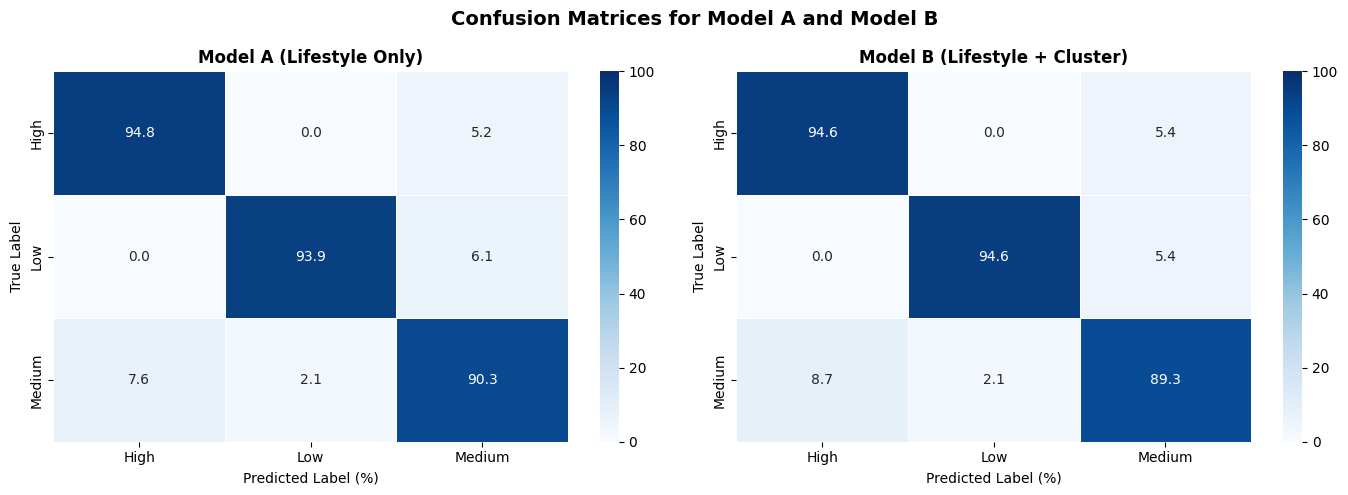

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

classes = ['High', 'Low', 'Medium']

test_pred_A = model_A.predict(X_test_A)
test_pred_B = model_B.predict(X_test_B)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in zip(axes,
                           [test_pred_A, test_pred_B],
                           ['Model A (Lifestyle Only)',
                            'Model B (Lifestyle + Cluster)']):
    cm = confusion_matrix(y_test, pred, labels=classes)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(
        cm_pct,
        annot=True,
        fmt='.1f',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes,
        ax=ax,
        linewidths=0.5,
        vmin=0,
        vmax=100
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label (%)', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.suptitle('Confusion Matrices for Model A and Model B',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_AB.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
import joblib
joblib.dump(model_A, "../models/model_A_lifestyle_only.pkl")
print("Model A saved!")

Model A saved!
